# Vessel-guided patch traversal: SmallENet (507) with border-following DFS

Instead of a fixed grid (every other full-image experiment this session), this
follows the vessel through the image patch-by-patch, using the
`nnUNetTrainerSmallENet` checkpoint trained on `Dataset507_ARCADE_refinement`
(1-channel baseline, ignores the predicted-mask channel -- see
`prepare_arcade_507_refinement.py`/the 507 recipe recap earlier).

**The point of this algorithm is to *avoid* scanning the whole image** --
only patches actually connected to a detected vessel get explored; the rest
are skipped entirely, not segmented at all.

**Algorithm**, per full 512x512 test image:

1. **Seed search**: check patches in a **clockwise spiral outward from the
   grid center** (not raster order) until one has **both** predicted vessel
   pixels *and* at least one registered exit direction (see step 2). A
   vessel is far more likely to cross the center of a cropped angiography
   frame than its corners, so spiraling out from the center tends to find a
   usable seed in fewer patches than scanning from the top-left. A patch
   with vessel but no exit direction (an isolated FP blob that doesn't reach
   any border) is not good enough -- keep spiraling past it. Every patch
   checked along the way is segmented once (unavoidable -- it's how you find
   out it's empty or isolated), and its prediction is kept in the stitched
   output either way.
2. Once a candidate seed is found, check its 4 edges (N/E/S/W) for predicted
   vessel within `BORDER_MARGIN` px of that edge -- a registered "exit
   direction" (vessel likely continues into the neighboring patch that way).
3. Follow **one** exit direction to that neighbor and repeat (depth-first)
   -- any *other* exit directions found along the way go on a backtracking
   stack instead of being explored immediately.
4. When the current thread dead-ends (no unvisited neighbor in any detected
   direction), pop the backtracking stack and resume from there.
5. **Retry-on-small-tree**: once the backtracking stack for this seed is
   empty, if the resulting tree has fewer than `MIN_TREE_SIZE` patches (its
   one exit direction led off-grid or immediately dead-ended, with nothing
   to backtrack to), the seed is rejected and the spiral search resumes
   from where it left off to find a better one. This is what catches the
   catastrophic-dead-end failure mode (a confident-but-isolated seed
   producing a 1-patch, dice=0 result) without falling back to full-image
   coverage.
6. **When a tree of adequate size is found (or the spiral is exhausted),
   the traversal stops** -- no attempt to find additional disconnected
   vessel components elsewhere in the image beyond what the accepted seed's
   tree and any rejected-seed patches already covered.

This deliberately does **not** guarantee full image coverage -- a
disconnected vessel fragment the spiral hasn't reached by the time an
adequate tree is found will never get segmented (stays background/0 in the
stitched output). That's the efficiency trade this algorithm is making, not
a bug.

Patches are placed on a fixed-step grid (`PATCH_SIZE`, step size derived from
`OVERLAP_FRAC`) so "the neighbor to the north" is a well-defined grid index,
not arbitrary pixel arithmetic. Overlapping patch predictions are stitched
by averaging.

A note on false positives: this checkpoint sometimes predicts vessel in
regions ARCADE's ground truth leaves unlabeled. Direct human review has
confirmed these are typically real, unlabeled vessels in the coronary tree
rather than pure hallucination -- a hidden true-positive that the reported
dice numbers here don't get credit for.

Tunable: `PATCH_SIZE`, `BORDER_MARGIN` (default 5px), `OVERLAP_FRAC` (default
0.15), `MIN_VESSEL_PX` (default 20), `MIN_TREE_SIZE` (default 5).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from PIL import Image

# Same numpy/torch checkpoint-loading fix used in every other preview
# notebook this session -- checkpoints trained under numpy>=2.0 fail to
# load under numpy 1.26.4's torch.load(..., weights_only=False).
import numpy.core.multiarray as _ma

_orig_scalar = _ma.scalar


def _patched_scalar(dtype, obj):
    if not isinstance(dtype, np.dtype):
        try:
            dtype = np.dtype(dtype.type) if hasattr(dtype, "type") else np.dtype(dtype)
        except Exception as e:
            raise TypeError(f"could not coerce {dtype!r} to np.dtype") from e
    return _orig_scalar(dtype, obj)


_ma.scalar = _patched_scalar


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
PACKAGE_ROOT = REPO_ROOT / "lightm-unet"
sys.path.insert(0, str(PACKAGE_ROOT))
from nnunetv2.nets.SmallENet import SmallENet  # noqa: E402

SOURCE_DIR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset501_ARCADE"
IMAGES_TS_DIR = SOURCE_DIR / "imagesTs"
LABELS_TS_DIR = SOURCE_DIR / "labelsTs"

CHECKPOINT_PATH = (
    REPO_ROOT / "data" / "nnUNET_results" / "Dataset507_ARCADE_refinement"
    / "nnUNetTrainerSmallENet__nnUNetPlans__2d" / "fold_0" / "checkpoint_best.pth"
)

METRICS_DIR = REPO_ROOT / "analysis" / "Dataset507_ARCADE_refinement" / "results_flood_fill"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Must match SmallENet defaults used to train the Dataset507 checkpoint.
INITIAL_CHANNELS = 16
STAGE_CHANNELS = 32
LCN_KERNEL_SIZE = 9
THRESHOLD = 0.5

# --- Tunable traversal parameters -------------------------------------------
PATCH_SIZE = 85          # SmallENet is resolution-agnostic (no pooling) -- 85 matches Dataset507's native patch size
BORDER_MARGIN = 5         # px from an edge that counts as "vessel reaches this border"
OVERLAP_FRAC = 0.15       # overlap between adjacent patches (grid step, and exploration step)
MIN_VESSEL_PX = 20        # noise filter -- SmallENet-507 has real FP hallucinations (confirmed: a 14px, 0.93-confidence
                           # false blob in a pure-background top-left corner patch); a bare pred.any() seed/exit check
                           # latches onto these immediately and dead-ends the traversal after 1 patch. Same
                           # minimum-blob-size convention as MIN_DISCONTINUITY_PX in prepare_arcade_507_refinement.py.
MIN_TREE_SIZE = 5         # retry threshold -- if a seed's DFS tree ends up smaller than this (e.g. its one exit
                           # direction led off-grid or immediately dead-ended), treat it as a bad seed and keep
                           # searching (spiraling) for a better one, instead of accepting a near-empty result.
N_RANDOM_CASES = 10
SEED = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repo root    :", REPO_ROOT)
print("Checkpoint   :", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("imagesTs     :", IMAGES_TS_DIR, len(list(IMAGES_TS_DIR.glob('*_0000.png'))))
print("Device       :", DEVICE)
print(f"PATCH_SIZE={PATCH_SIZE} BORDER_MARGIN={BORDER_MARGIN} OVERLAP_FRAC={OVERLAP_FRAC} "
      f"MIN_VESSEL_PX={MIN_VESSEL_PX} MIN_TREE_SIZE={MIN_TREE_SIZE}")

Repo root    : /workspace/LightM-UNet
Checkpoint   : /workspace/LightM-UNet/data/nnUNET_results/Dataset507_ARCADE_refinement/nnUNetTrainerSmallENet__nnUNetPlans__2d/fold_0/checkpoint_best.pth True
imagesTs     : /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/imagesTs 300
Device       : cuda
PATCH_SIZE=85 BORDER_MARGIN=5 OVERLAP_FRAC=0.15 MIN_VESSEL_PX=20 MIN_TREE_SIZE=5


In [2]:
model = SmallENet(
    in_channels=1, out_channels=1,
    initial_channels=INITIAL_CHANNELS, stage_channels=STAGE_CHANNELS, lcn_kernel_size=LCN_KERNEL_SIZE,
)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["network_weights"])
model = model.to(DEVICE).eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('current_epoch')}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Loaded checkpoint from epoch 149
Params: 8,297


## Traversal algorithm

In [3]:
def load_gray(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def load_gt(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr > 0


def zscore_normalize(image: np.ndarray) -> np.ndarray:
    mean = image.mean()
    std = image.std()
    return (image - mean) / max(std, 1e-8)


def compute_starts(size: int, patch_size: int, stride: int) -> list[int]:
    """Sliding-window grid positions covering [0, size], last one clamped to
    size - patch_size so it always reaches the far edge."""
    if size <= patch_size:
        return [0]
    starts = list(range(0, size - patch_size + 1, stride))
    if starts[-1] != size - patch_size:
        starts.append(size - patch_size)
    return starts


DIRECTIONS = {"N": (-1, 0), "S": (1, 0), "E": (0, 1), "W": (0, -1)}


@torch.no_grad()
def infer_patch(raw_patch: np.ndarray) -> np.ndarray:
    normed = zscore_normalize(raw_patch)
    x = torch.from_numpy(normed).float()[None, None].to(DEVICE)
    logits = model(x)
    return torch.sigmoid(logits)[0, 0].cpu().numpy()


def exit_directions(pred_mask: np.ndarray, border_margin: int, min_vessel_px: int) -> list[str]:
    """Which of N/E/S/W have at least min_vessel_px predicted-vessel pixels
    within border_margin px of that edge -- i.e. vessel likely continues
    into that neighbor. min_vessel_px is a noise filter: SmallENet-507 has
    real FP hallucinations (confirmed directly -- a 14px, 0.93-confidence
    false blob in a pure-background patch), so a bare >0 pixel check treats
    those the same as a real vessel edge-crossing."""
    if pred_mask.sum() < min_vessel_px:
        return []
    h, w = pred_mask.shape
    m = min(border_margin, h, w)
    dirs = []
    if pred_mask[:m, :].sum() >= min_vessel_px:
        dirs.append("N")
    if pred_mask[-m:, :].sum() >= min_vessel_px:
        dirs.append("S")
    if pred_mask[:, :m].sum() >= min_vessel_px:
        dirs.append("W")
    if pred_mask[:, -m:].sum() >= min_vessel_px:
        dirs.append("E")
    return dirs


def spiral_positions(n_rows: int, n_cols: int) -> list[tuple[int, int]]:
    """Clockwise square-spiral order starting from the grid center (E -> S ->
    W -> N, step length incrementing every 2 direction changes), covering
    every (row, col) cell exactly once. Used as the seed-search order instead
    of top-left raster -- a vessel is far more likely to pass near the center
    of a cropped angiography frame than its corners, so spiraling outward
    from the center tends to find a usable seed in fewer patches on average."""
    total = n_rows * n_cols
    cr, cc = n_rows // 2, n_cols // 2
    positions: list[tuple[int, int]] = []
    seen: set[tuple[int, int]] = set()

    def maybe_add(r, c):
        if 0 <= r < n_rows and 0 <= c < n_cols and (r, c) not in seen:
            positions.append((r, c))
            seen.add((r, c))

    r, c = cr, cc
    maybe_add(r, c)

    dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # E, S, W, N -- clockwise
    step_len = 1
    dir_idx = 0
    max_step_len = n_rows + n_cols + 2  # safety cap

    while len(positions) < total and step_len <= max_step_len:
        for _ in range(2):
            dr, dc = dirs[dir_idx % 4]
            for _ in range(step_len):
                r += dr
                c += dc
                maybe_add(r, c)
            dir_idx += 1
        step_len += 1

    if len(positions) < total:  # fallback safety net, shouldn't normally trigger
        for rr in range(n_rows):
            for cc2 in range(n_cols):
                maybe_add(rr, cc2)

    return positions


def traverse_image(
    raw: np.ndarray,
    patch_size: int = PATCH_SIZE,
    border_margin: int = BORDER_MARGIN,
    overlap_frac: float = OVERLAP_FRAC,
    min_vessel_px: int = MIN_VESSEL_PX,
    min_tree_size: int = MIN_TREE_SIZE,
) -> dict:
    """Seed search (clockwise spiral from the grid center -- see
    spiral_positions) to find a patch that has BOTH vessel AND at least one
    registered exit direction -- a patch with vessel but no exit direction
    (e.g. an isolated FP blob that doesn't reach any border) is not good
    enough, keep spiraling past it. Then pure DFS+backtrack over *detected*
    exit directions -- terminates as soon as that's exhausted. Does NOT
    guarantee full image coverage -- see the markdown cell above for why
    that's the point.

    Retry-on-small-tree: if a seed's resulting DFS tree ends up smaller than
    min_tree_size (its one exit direction led off-grid or immediately
    dead-ended, with nothing to backtrack to), that seed is rejected and the
    spiral search resumes from where it left off to find a better one --
    same "skip when the tree ends" philosophy, just applied at the seed
    level too instead of accepting a near-empty (often dice=0) result
    outright. Every patch inferred along the way -- including from rejected
    seeds -- stays in the accumulated prob_sum/weight_sum; nothing already
    computed is thrown away, only the seed choice is retried.
    """
    h, w = raw.shape
    stride = max(1, int(round(patch_size * (1 - overlap_frac))))
    y_starts = compute_starts(h, patch_size, stride)
    x_starts = compute_starts(w, patch_size, stride)
    n_rows, n_cols = len(y_starts), len(x_starts)

    prob_sum = np.zeros((h, w), dtype=np.float32)
    weight_sum = np.zeros((h, w), dtype=np.float32)

    visited: set[tuple[int, int]] = set()
    order: list[tuple[int, int]] = []
    registered_directions: dict[tuple[int, int], list[str]] = {}
    backtrack_stack: list[tuple[int, int]] = []

    def neighbor(pos: tuple[int, int], direction: str) -> tuple[int, int] | None:
        dr, dc = DIRECTIONS[direction]
        nr, nc = pos[0] + dr, pos[1] + dc
        if 0 <= nr < n_rows and 0 <= nc < n_cols:
            return (nr, nc)
        return None

    def process(pos: tuple[int, int]) -> list[str]:
        row_idx, col_idx = pos
        visited.add(pos)
        order.append(pos)
        y0, x0 = y_starts[row_idx], x_starts[col_idx]
        y1, x1 = y0 + patch_size, x0 + patch_size
        patch = raw[y0:y1, x0:x1]
        prob = infer_patch(patch)
        prob_sum[y0:y1, x0:x1] += prob
        weight_sum[y0:y1, x0:x1] += 1.0
        pred = prob > THRESHOLD
        dirs = exit_directions(pred, border_margin, min_vessel_px)
        registered_directions[pos] = dirs
        return dirs

    # -- Seed search: clockwise spiral out from the grid center, segmenting
    # each unvisited patch just to check it, until one has vessel AND at
    # least one exit direction. A patch with vessel but zero exit
    # directions (isolated blob, doesn't reach any border) is not a valid
    # seed -- keep spiraling past it.
    search_positions = spiral_positions(n_rows, n_cols)
    search_idx = 0
    seed: tuple[int, int] | None = None

    while search_idx < len(search_positions):
        cand_seed: tuple[int, int] | None = None
        cand_dirs: list[str] = []
        while search_idx < len(search_positions):
            pos = search_positions[search_idx]
            search_idx += 1
            if pos in visited:
                continue
            dirs = process(pos)
            if dirs:
                cand_seed, cand_dirs = pos, dirs
                break

        if cand_seed is None:
            break  # spiral exhausted, never found a usable seed

        # -- DFS + backtrack over *detected* directions only, from this
        # candidate seed -- no raster/spiral fallback once this is
        # exhausted ("skip when the tree ends").
        tree_start_len = len(order)
        local_stack: list[tuple[int, int]] = []
        current, dirs = cand_seed, cand_dirs
        while True:
            follow_to = None
            for d in dirs:
                nb = neighbor(current, d)
                if nb is not None and nb not in visited:
                    if follow_to is None:
                        follow_to = nb
                    else:
                        local_stack.append(nb)

            if follow_to is not None:
                current = follow_to
                dirs = process(current)
            elif local_stack:
                current = local_stack.pop()
                while current in visited and local_stack:
                    current = local_stack.pop()
                if current in visited:
                    break
                dirs = process(current)
            else:
                break

        tree_size = len(order) - tree_start_len
        if tree_size >= min_tree_size:
            seed = cand_seed
            backtrack_stack = local_stack  # already exhausted, kept only for inspection
            break
        # else: tree too small (catastrophic dead-end) -- its patches stay in
        # prob_sum/weight_sum, but this seed is rejected; spiral continues.

    stitched_prob = prob_sum / np.maximum(weight_sum, 1e-8)  # 0/0 -> nan outside visited patches
    stitched_prob = np.nan_to_num(stitched_prob, nan=0.0)
    return {
        "prob": stitched_prob,
        "pred": stitched_prob > THRESHOLD,
        "order": order,
        "seed": seed,
        "directions": registered_directions,
        "y_starts": y_starts, "x_starts": x_starts,
        "n_rows": n_rows, "n_cols": n_cols,
        "patch_size": patch_size,
        "visited_mask": weight_sum > 0,
    }

## Run on 10 random test images, compute dice, visualize traversal + result

In [4]:
def dice_score(gt: np.ndarray, pred: np.ndarray) -> float:
    tp = int((gt & pred).sum())
    fp = int((~gt & pred).sum())
    fn = int((gt & ~pred).sum())
    return (2 * tp) / (2 * tp + fp + fn + 1e-8)


rng = np.random.default_rng(SEED)
img_files = sorted(IMAGES_TS_DIR.glob("*_0000.png"))
chosen = rng.choice(len(img_files), size=N_RANDOM_CASES, replace=False)

results = []
cases = []
for i in chosen:
    img_path = img_files[i]
    case_id = img_path.stem[: -len("_0000")]
    gt_path = LABELS_TS_DIR / f"{case_id}.png"

    raw = load_gray(img_path)
    gt = load_gt(gt_path)

    result = traverse_image(raw)
    d = dice_score(gt, result["pred"])

    n_cells = result["n_rows"] * result["n_cols"]
    n_with_exits = sum(1 for v in result["directions"].values() if v)
    pct_skipped = 100.0 * (1 - len(result["order"]) / n_cells)
    results.append({
        "case_id": case_id, "dice": d, "n_cells_visited": len(result["order"]),
        "n_cells_total": n_cells, "pct_cells_skipped": pct_skipped,
        "n_cells_with_exit_directions": n_with_exits, "seed_found": result["seed"] is not None,
    })
    cases.append({"case_id": case_id, "raw": raw, "gt": gt, "result": result})
    print(f"{case_id}: dice={d:.4f}  cells={len(result['order'])}/{n_cells} ({pct_skipped:.0f}% skipped)  "
          f"seed={result['seed']}")

results_df = pd.DataFrame(results)
results_df.to_csv(METRICS_DIR / "flood_fill_dice.csv", index=False)
print()
display(results_df)
print("\nMean dice:", results_df["dice"].mean())
print("Mean %% cells skipped (never segmented):", results_df["pct_cells_skipped"].mean())

test_52: dice=0.6803  cells=15/49 (69% skipped)  seed=(4, 4)
test_49: dice=0.5660  cells=6/49 (88% skipped)  seed=(3, 3)
test_268: dice=0.6531  cells=24/49 (51% skipped)  seed=(3, 3)


test_235: dice=0.4990  cells=30/49 (39% skipped)  seed=(1, 1)
test_172: dice=0.7234  cells=17/49 (65% skipped)  seed=(3, 3)


test_111: dice=0.4063  cells=49/49 (0% skipped)  seed=None
test_104: dice=0.8220  cells=18/49 (63% skipped)  seed=(3, 3)
test_182: dice=0.4638  cells=9/49 (82% skipped)  seed=(3, 3)


test_148: dice=0.6486  cells=16/49 (67% skipped)  seed=(3, 3)
test_120: dice=0.3844  cells=16/49 (67% skipped)  seed=(3, 3)



,case_id,dice,n_cells_visited,n_cells_total,pct_cells_skipped,n_cells_with_exit_directions,seed_found
0,test_52,0.680336,15,49,69.387755,13,True
1,test_49,0.566012,6,49,87.755102,4,True
2,test_268,0.653129,24,49,51.020408,22,True
3,test_235,0.498960,30,49,38.775510,16,True
4,test_172,0.723369,17,49,65.306122,14,True
5,test_111,0.406277,49,49,0.000000,14,False
6,test_104,0.822030,18,49,63.265306,15,True
7,test_182,0.463846,9,49,81.632653,9,True
8,test_148,0.648625,16,49,67.346939,12,True
9,test_120,0.384351,16,49,67.346939,13,True



Mean dice: 0.5846934529595273
Mean %% cells skipped (never segmented): 59.183673469387756


## Visualize: raw + traversal path, GT, prediction, confusion

Traversal path: patch centers connected in visit order, colored early (dark
purple) -> late (yellow) via the `viridis` colormap -- makes the
follow-one-direction-then-backtrack behavior visible (long smooth runs along
a vessel, then a jump back to resume an earlier branch or the raster
fallback).

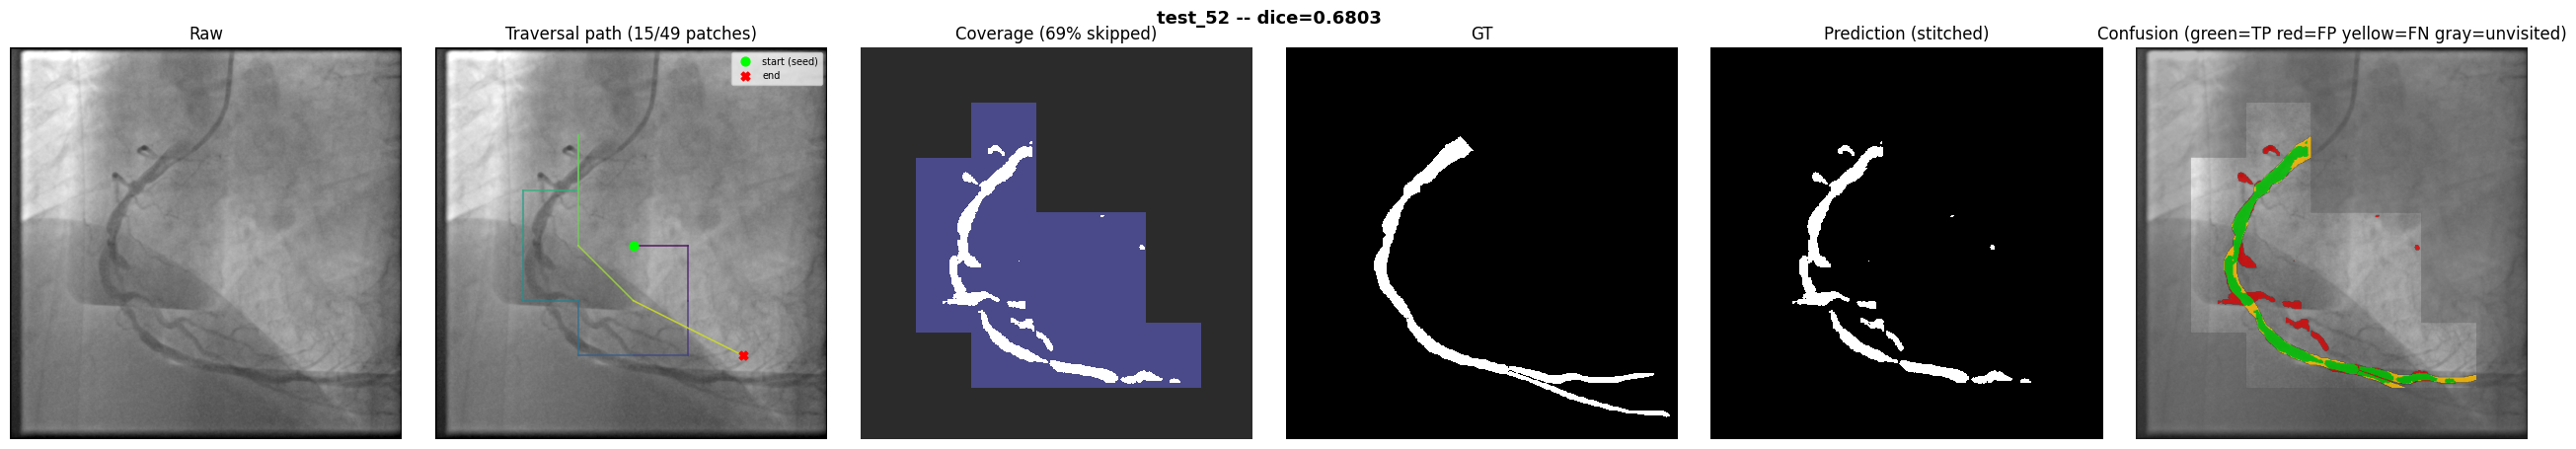

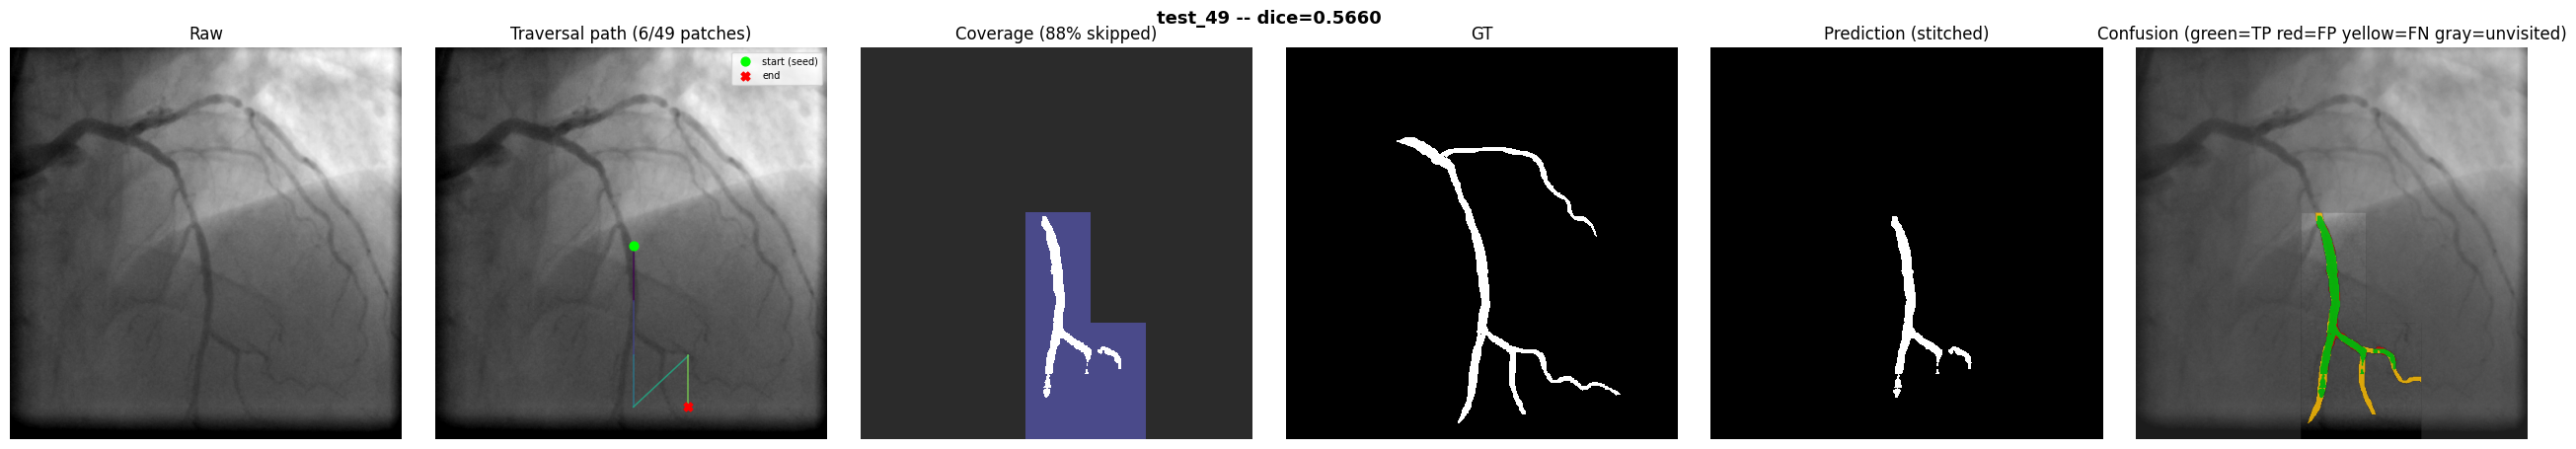

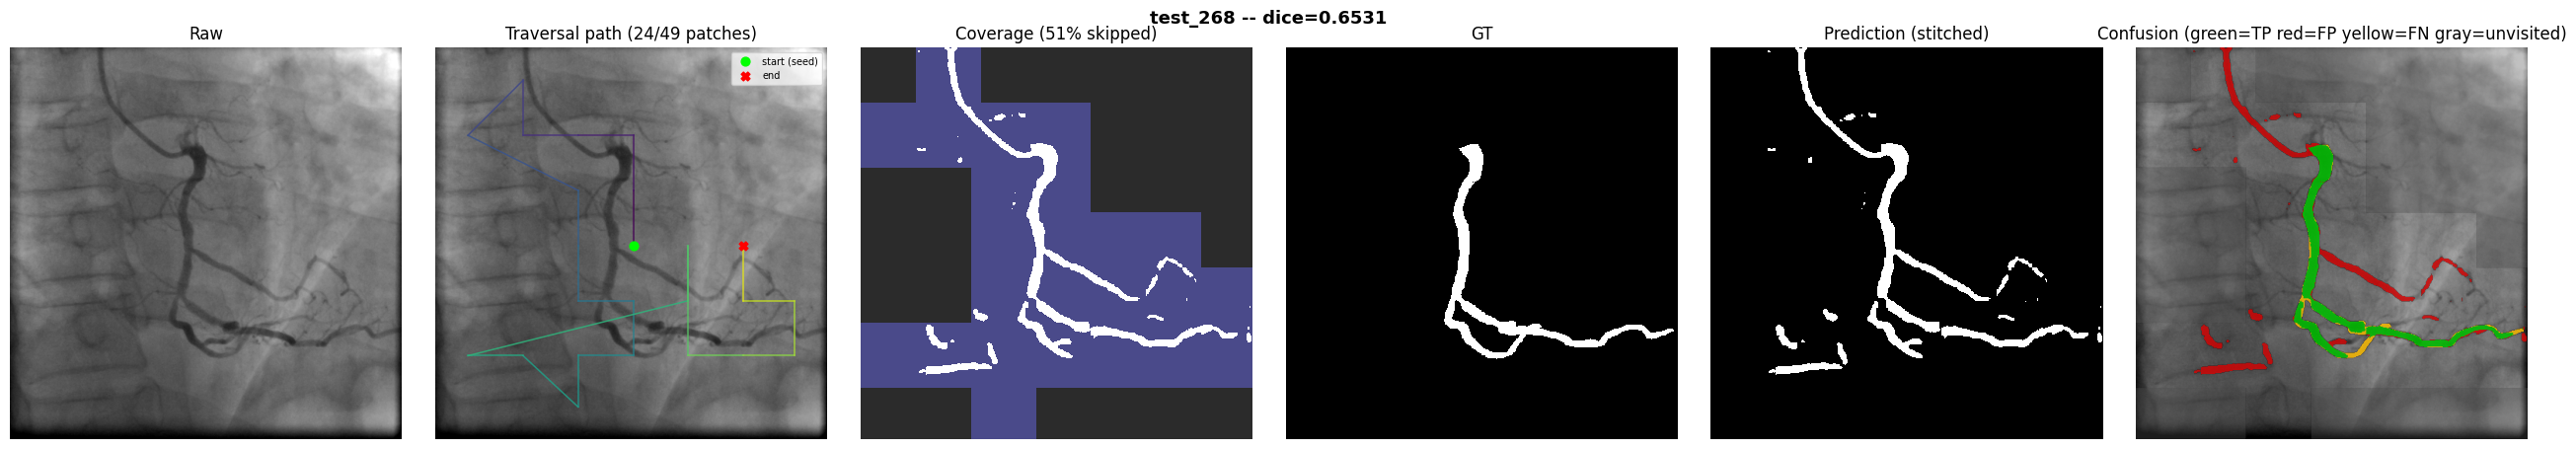

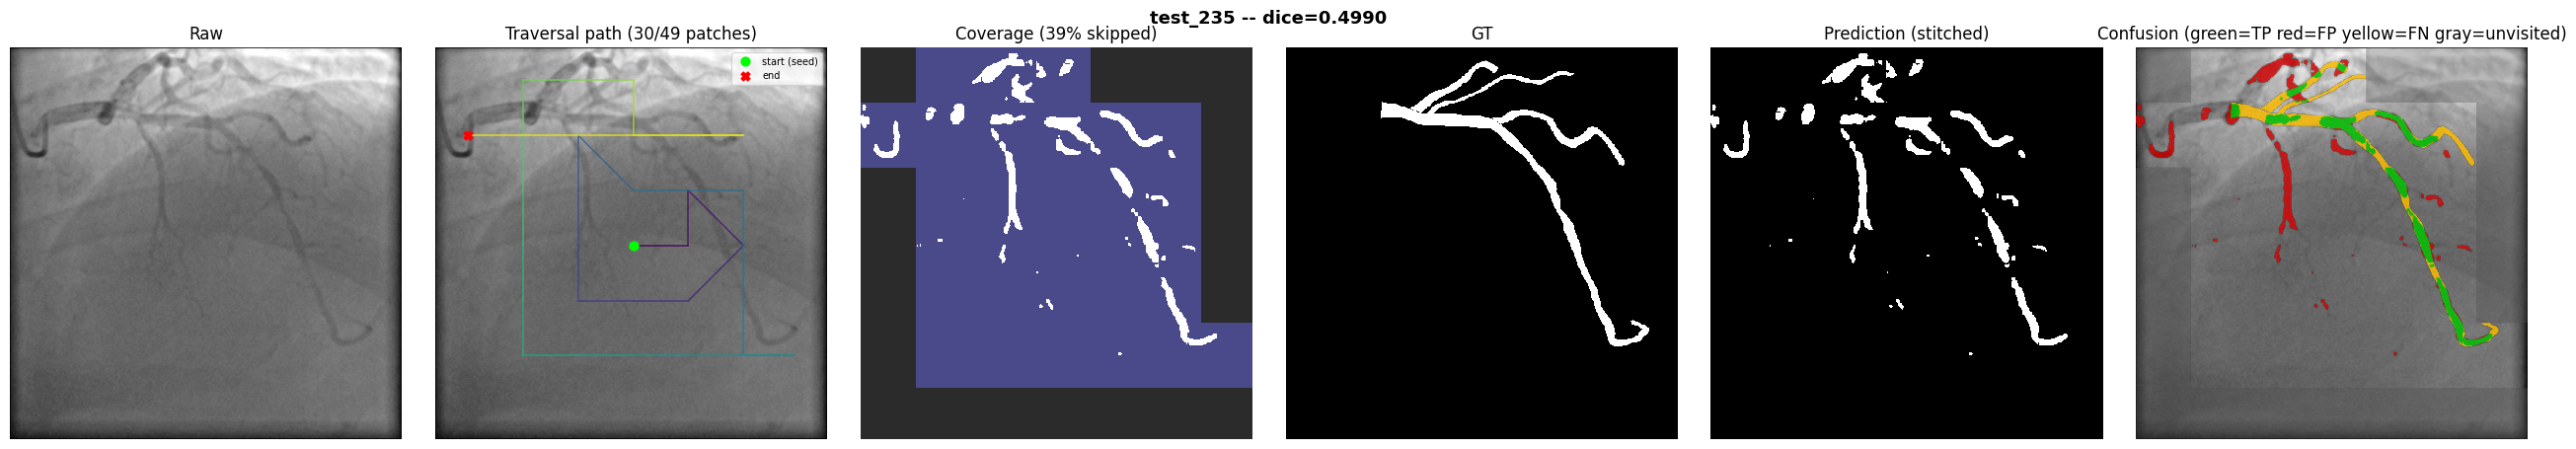

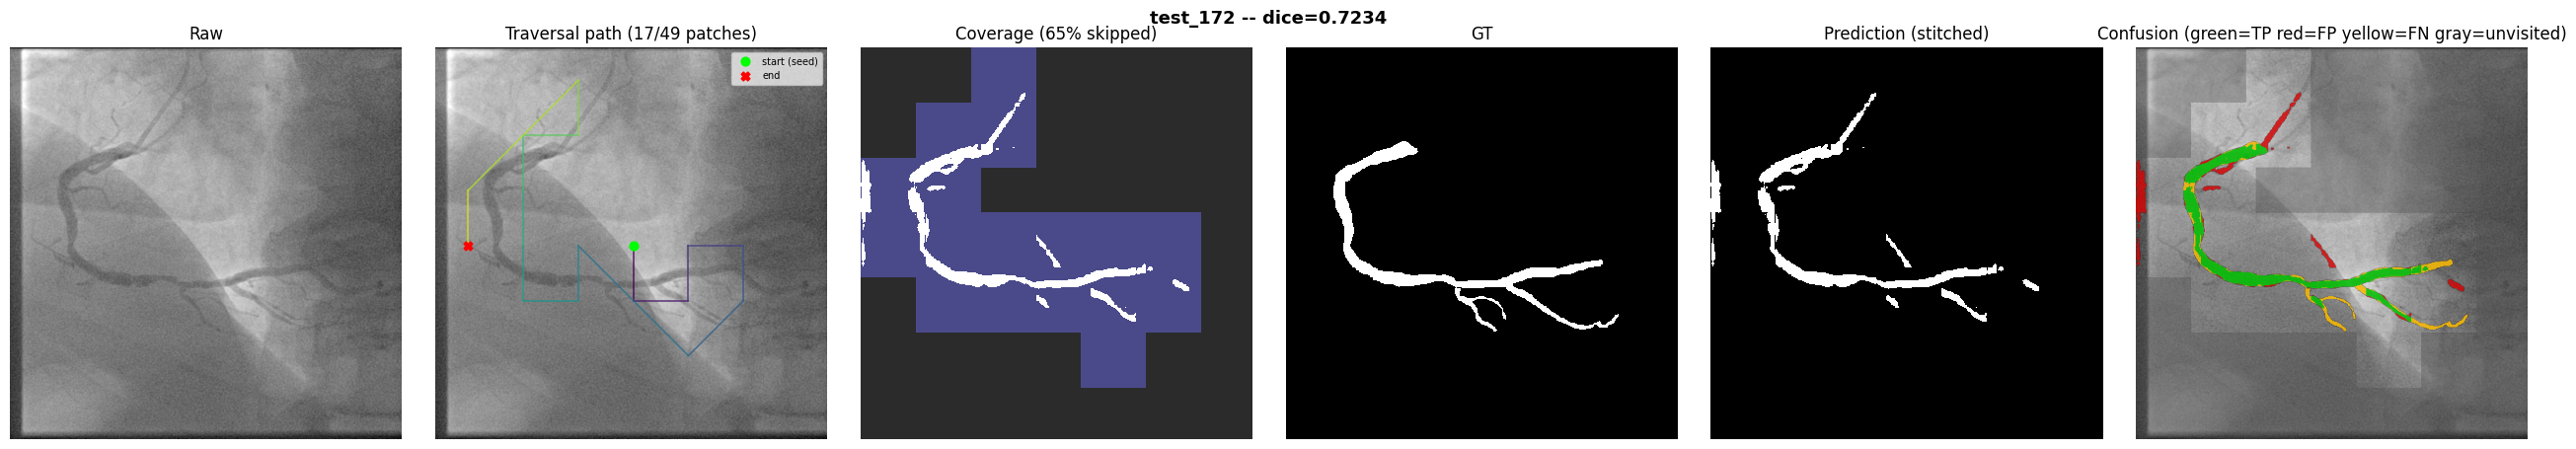

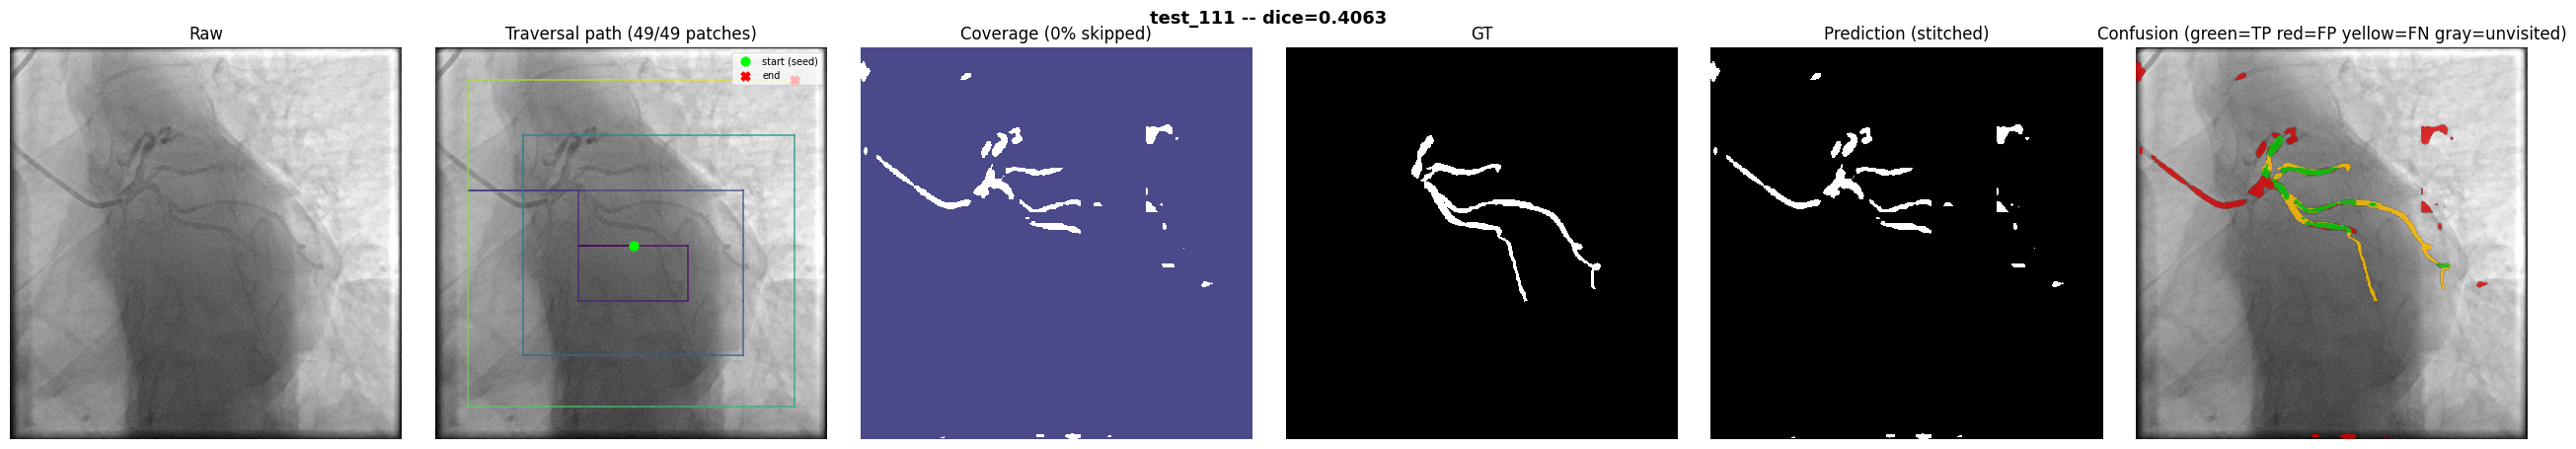

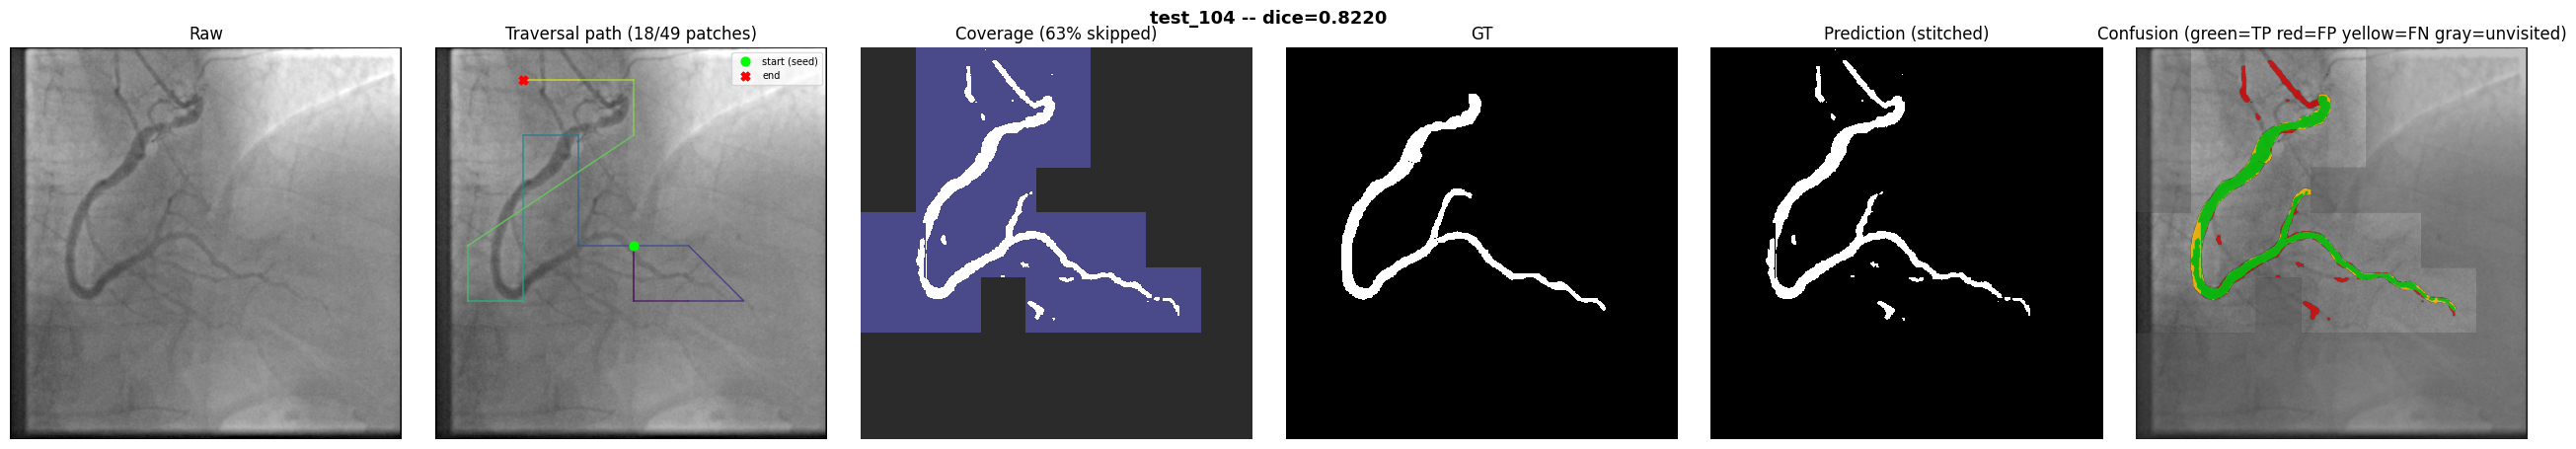

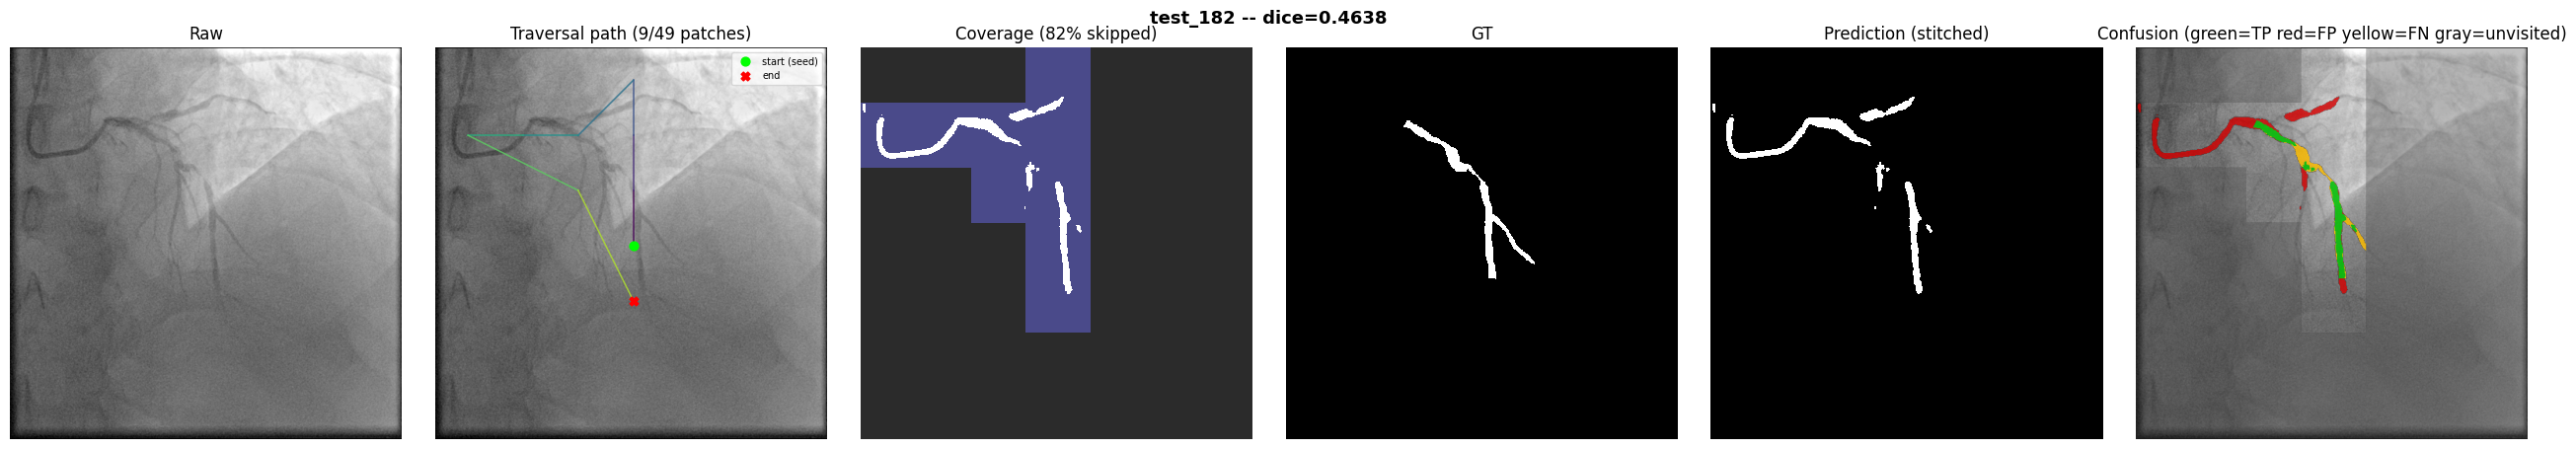

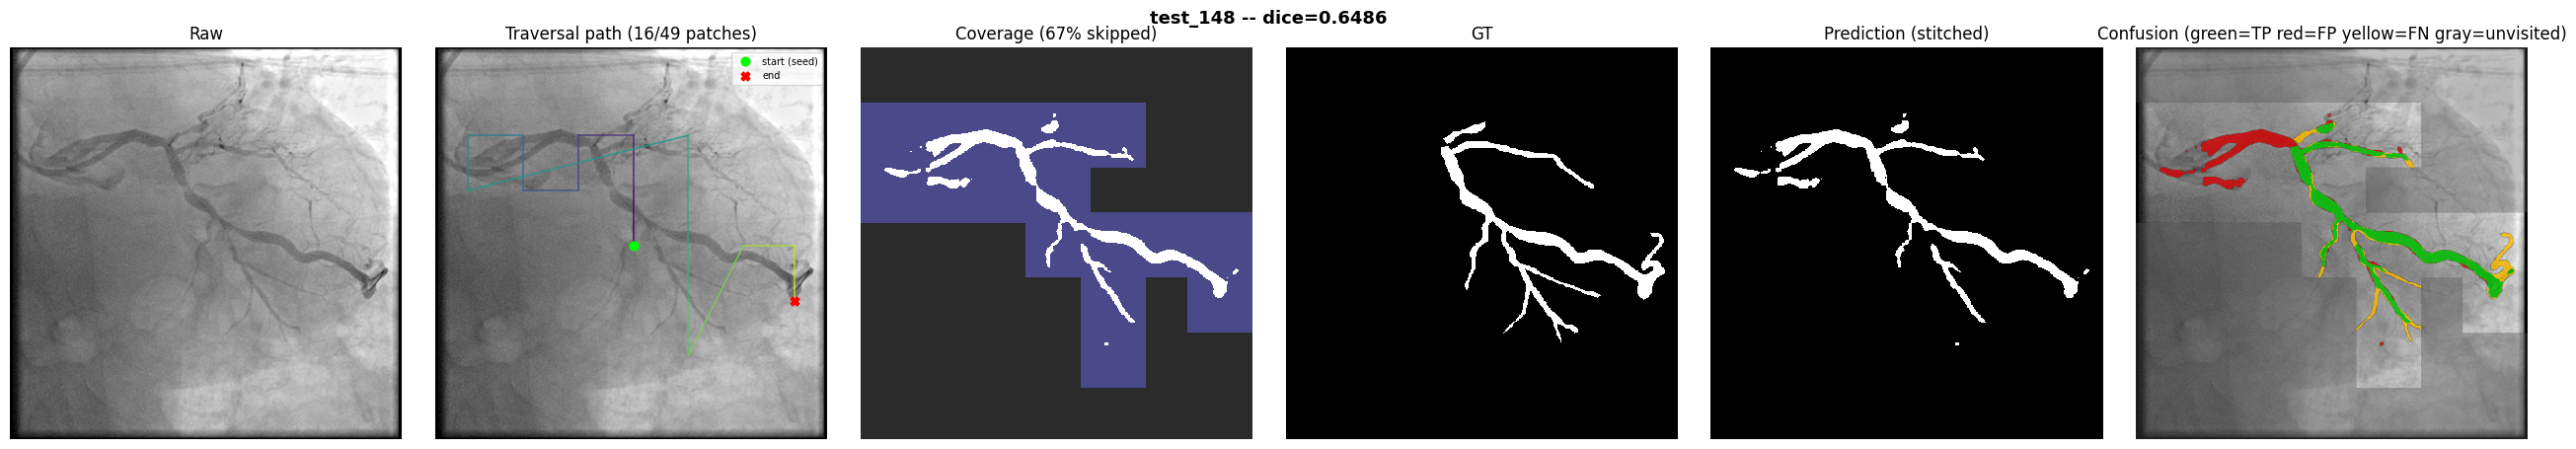

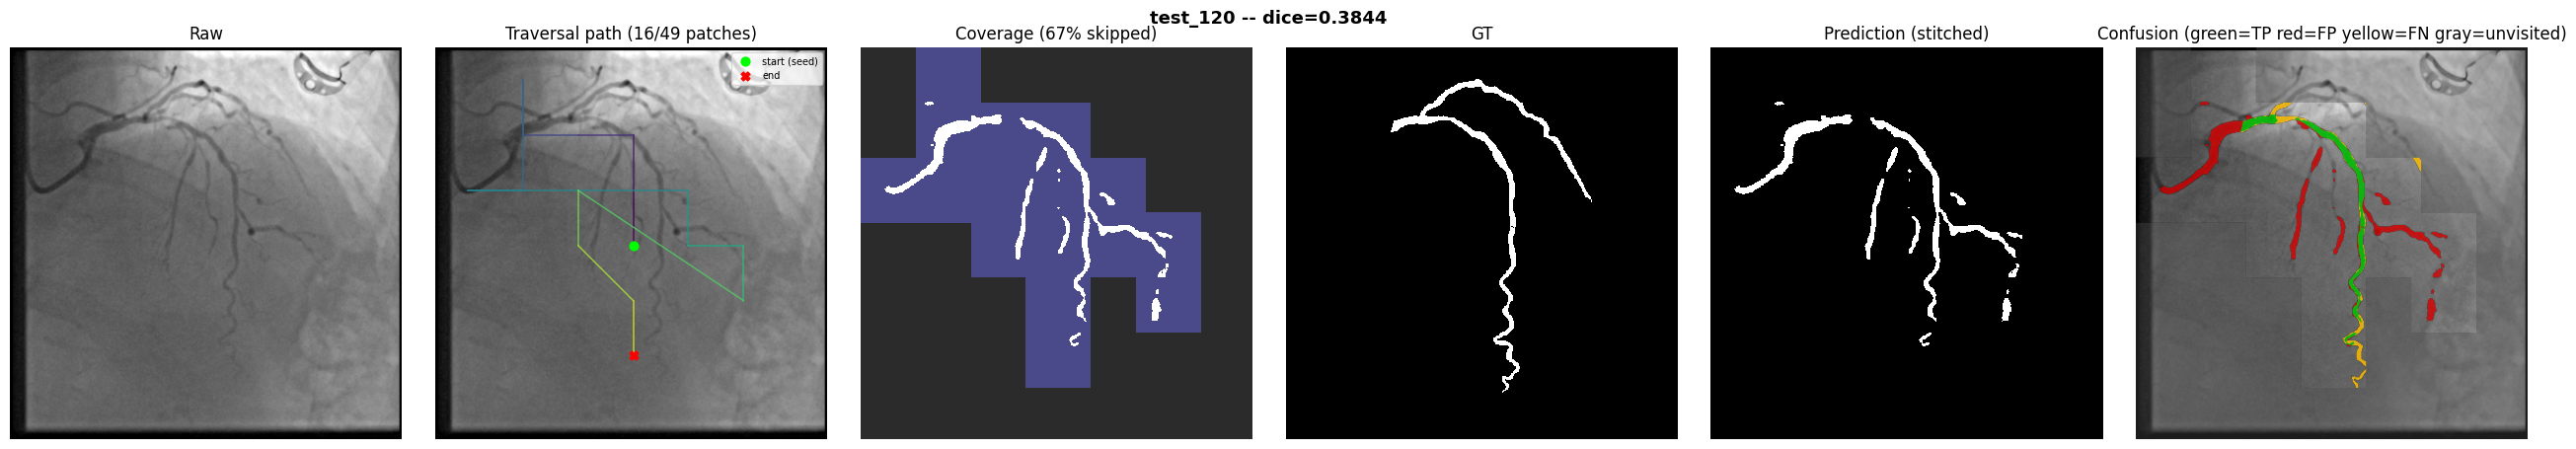

In [5]:
IMSHOW_MASK_KW = dict(cmap=mcolors.ListedColormap(["#000000", "#ffffff"]), norm=mcolors.BoundaryNorm([0, 1, 2], 2), interpolation="nearest")


def make_confusion(gt: np.ndarray, pred: np.ndarray, visited_mask: np.ndarray) -> np.ndarray:
    overlay = np.zeros((*gt.shape, 4), dtype=np.uint8)
    overlay[gt & pred] = [0, 200, 0, 210]
    overlay[~gt & pred] = [220, 0, 0, 200]
    overlay[gt & ~pred] = [255, 190, 0, 210]
    overlay[~visited_mask] = [80, 80, 80, 90]  # never-visited region, distinct from "visited and predicted background"
    return overlay


def coverage_display(pred: np.ndarray, visited_mask: np.ndarray) -> np.ndarray:
    """0=unvisited (never segmented), 1=visited+background, 2=visited+vessel."""
    disp = np.zeros(pred.shape, dtype=np.uint8)
    disp[visited_mask] = 1
    disp[visited_mask & pred] = 2
    return disp


COVERAGE_CMAP = mcolors.ListedColormap(["#2b2b2b", "#4a4a8a", "#ffffff"])  # unvisited / visited-bg / visited-vessel
COVERAGE_NORM = mcolors.BoundaryNorm([0, 1, 2, 3], 3)


def draw_traversal_path(ax, result: dict):
    order = result["order"]
    y_starts, x_starts = result["y_starts"], result["x_starts"]
    ps = result["patch_size"]
    centers = [(x_starts[c] + ps / 2, y_starts[r] + ps / 2) for r, c in order]
    xs = [c[0] for c in centers]
    ys = [c[1] for c in centers]
    n = len(centers)
    cmap = plt.get_cmap("viridis")
    for i in range(n - 1):
        ax.plot(xs[i:i + 2], ys[i:i + 2], color=cmap(i / max(n - 1, 1)), linewidth=1.1, alpha=0.85)
    ax.scatter(xs[0], ys[0], color="lime", s=40, marker="o", zorder=5, label="start (seed)")
    ax.scatter(xs[-1], ys[-1], color="red", s=40, marker="X", zorder=5, label="end")


for case in cases:
    raw, gt, result = case["raw"], case["gt"], case["result"]
    pred = result["pred"]
    visited_mask = result["visited_mask"]
    row = results_df[results_df["case_id"] == case["case_id"]].iloc[0]

    fig, axes = plt.subplots(1, 6, figsize=(26, 4.6))

    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Raw")
    axes[0].axis("off")

    axes[1].imshow(raw, cmap="gray")
    draw_traversal_path(axes[1], result)
    axes[1].legend(loc="upper right", fontsize=7, framealpha=0.7)
    axes[1].set_title(f"Traversal path ({len(result['order'])}/{row['n_cells_total']} patches)")
    axes[1].axis("off")

    axes[2].imshow(coverage_display(pred, visited_mask), cmap=COVERAGE_CMAP, norm=COVERAGE_NORM, interpolation="nearest")
    axes[2].set_title(f"Coverage ({row['pct_cells_skipped']:.0f}% skipped)")
    axes[2].axis("off")

    axes[3].imshow(gt, **IMSHOW_MASK_KW)
    axes[3].set_title("GT")
    axes[3].axis("off")

    axes[4].imshow(pred, **IMSHOW_MASK_KW)
    axes[4].set_title("Prediction (stitched)")
    axes[4].axis("off")

    axes[5].imshow(raw, cmap="gray")
    axes[5].imshow(make_confusion(gt, pred, visited_mask))
    axes[5].set_title("Confusion (green=TP red=FP yellow=FN gray=unvisited)")
    axes[5].axis("off")

    fig.suptitle(f"{case['case_id']} -- dice={row['dice']:.4f}", fontweight="bold", fontsize=13)
    plt.tight_layout()
    fig.savefig(METRICS_DIR / f"{case['case_id']}_flood_fill_panel.png", dpi=130, bbox_inches="tight")
    plt.show()